# Compare Average Context Length Per Query

This notebook compares the average `ctx` length used for each query in:

- `outputs/eval-longbench-hotpotqa.jsonl`
- `outputs/eval-longbench-hotpotqa-summ.jsonl`

Length is measured in characters by default.

In [58]:
from pathlib import Path
import json
import statistics

import pandas as pd
import matplotlib.pyplot as plt
import os

plt.style.use('ggplot')

In [59]:
ROOT = "/mnt/nvme1/dongseob/matkv/outputs"

base_path = Path(os.path.join(ROOT, 'eval-longbench-hotpotqa.jsonl'))
summ_path = Path(os.path.join(ROOT ,'eval-longbench-hotpotqa-summ.jsonl'))
compare_path = Path(os.path.join(ROOT ,'eval-longbench-hotpotqa-compare.jsonl'))

base_path, summ_path, compare_path

(PosixPath('/mnt/nvme1/dongseob/matkv/outputs/eval-longbench-hotpotqa.jsonl'),
 PosixPath('/mnt/nvme1/dongseob/matkv/outputs/eval-longbench-hotpotqa-summ.jsonl'),
 PosixPath('/mnt/nvme1/dongseob/matkv/outputs/eval-longbench-hotpotqa-compare.jsonl'))

In [60]:
def load_jsonl(path: Path):
    records = []
    with path.open('r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            records.append(json.loads(line))
    return records

def ctx_avg_char_length(record):
    ctxs = record.get('ctxs', [])
    lengths = [len(ctx.get('text', '')) for ctx in ctxs]
    return statistics.mean(lengths) if lengths else 0

def to_df(records, label):
    rows = []
    for idx, record in enumerate(records):
        ctxs = record.get('ctxs', [])
        lengths = [len(ctx.get('text', '')) for ctx in ctxs]
        rows.append({
            'query_idx': idx,
            'question': record.get('question', ''),
            f'ctx_count_{label}': len(ctxs),
            f'ctx_total_chars_{label}': sum(lengths),
            f'ctx_avg_chars_{label}': statistics.mean(lengths) if lengths else 0,
        })
    return pd.DataFrame(rows)

base_records = load_jsonl(base_path)
summ_records = load_jsonl(summ_path)
compare_records = load_jsonl(compare_path)

df_base = to_df(base_records, 'base')
df_summ = to_df(summ_records, 'summ')
df_compare = to_df(compare_records, 'compare')

comparison = df_base.merge(df_summ, on=['query_idx', 'question'], how='outer')
comparison = comparison.merge(df_compare, on=['query_idx', 'question'], how='outer')

comparison.head()

,query_idx,question,ctx_count_base,ctx_total_chars_base,ctx_avg_chars_base,ctx_count_summ,ctx_total_chars_summ,ctx_avg_chars_summ,ctx_count_compare,ctx_total_chars_compare,ctx_avg_chars_compare
0,0,Which case was brought to court first Miller v...,5,16729,3345.8,5,8508,1701.6,5,5625,1125.0
1,1,"The actor that plays Phileas Fogg in ""Around t...",5,20700,4140.0,5,2338,467.6,5,8927,1785.4
2,2,"Prior to playing for Michigan State, Keith Nic...",5,15325,3065.0,5,11384,2276.8,5,6371,1274.2
3,3,Gary L. Bennett was a part of the space missio...,5,15198,3039.6,5,1652,330.4,5,6442,1288.4
4,4,Was Atom Egoyans biggest commercial success on...,5,7805,1561.0,5,4065,813.0,5,3941,788.2


In [61]:
summary = pd.DataFrame([
    {
        'file': 'eval-longbench-hotpotqa.jsonl',
        'queries': len(df_base),
        'min_ctx_avg_chars': df_base['ctx_avg_chars_base'].min(),
        'max_ctx_avg_chars': df_base['ctx_avg_chars_base'].max(),
        'mean_ctx_avg_chars': df_base['ctx_avg_chars_base'].mean(),
        'median_ctx_avg_chars': df_base['ctx_avg_chars_base'].median(),
        'mean_ctx_total_chars': df_base['ctx_total_chars_base'].mean(),
    },
    {
        'file': 'eval-longbench-hotpotqa-summ.jsonl',
        'queries': len(df_summ),
        'min_ctx_avg_chars': df_summ['ctx_avg_chars_summ'].min(),
        'max_ctx_avg_chars': df_summ['ctx_avg_chars_summ'].max(),
        'mean_ctx_avg_chars': df_summ['ctx_avg_chars_summ'].mean(),
        'median_ctx_avg_chars': df_summ['ctx_avg_chars_summ'].median(),
        'mean_ctx_total_chars': df_summ['ctx_total_chars_summ'].mean(),
    },
    {
        'file': 'eval-longbench-hotpotqa-compare.jsonl',
        'queries': len(df_compare),
        'min_ctx_avg_chars': df_compare['ctx_avg_chars_compare'].min(),
        'max_ctx_avg_chars': df_compare['ctx_avg_chars_compare'].max(),
        'mean_ctx_avg_chars': df_compare['ctx_avg_chars_compare'].mean(),
        'median_ctx_avg_chars': df_compare['ctx_avg_chars_compare'].median(),
        'mean_ctx_total_chars': df_compare['ctx_total_chars_compare'].mean(),
    },
])

summary

,file,queries,min_ctx_avg_chars,max_ctx_avg_chars,mean_ctx_avg_chars,median_ctx_avg_chars,mean_ctx_total_chars
0,eval-longbench-hotpotqa.jsonl,200,623.0,4928.6,3108.101,3166.4,15540.505
1,eval-longbench-hotpotqa-summ.jsonl,200,173.0,3481.4,947.266,478.4,4736.330
2,eval-longbench-hotpotqa-compare.jsonl,200,250.8,2218.2,1287.188,1285.6,6435.940


In [57]:
comparison[['query_idx', 'question', 'ctx_avg_chars_base', 'ctx_avg_chars_summ', 'avg_char_diff']].head(10)

KeyError: "['avg_char_diff'] not in index"

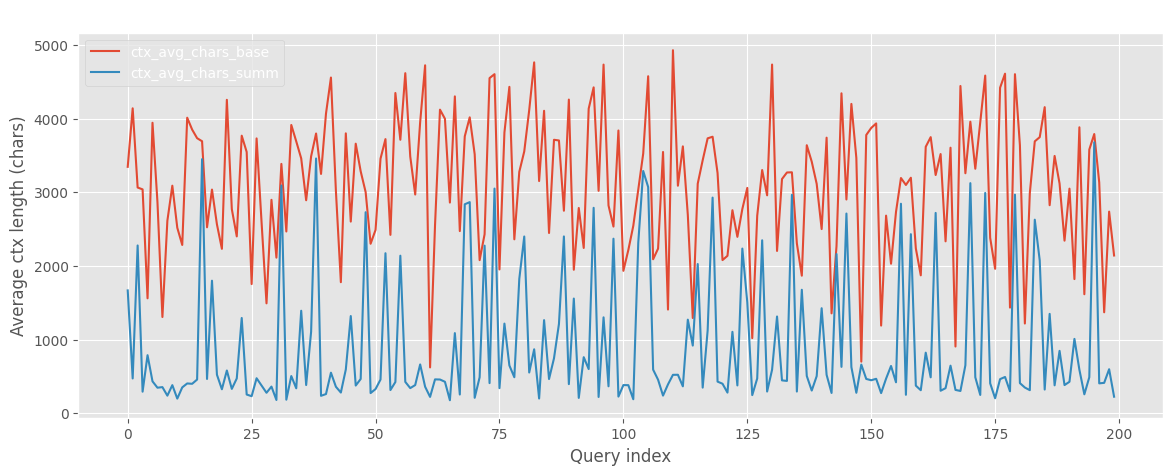

In [42]:
ax = comparison.plot(
    x='query_idx',
    y=['ctx_avg_chars_base', 'ctx_avg_chars_summ'],
    figsize=(14, 5),
    title='Average Context Length per Query (characters)'
)
ax.set_xlabel('Query index')
ax.set_ylabel('Average ctx length (chars)')
plt.show()

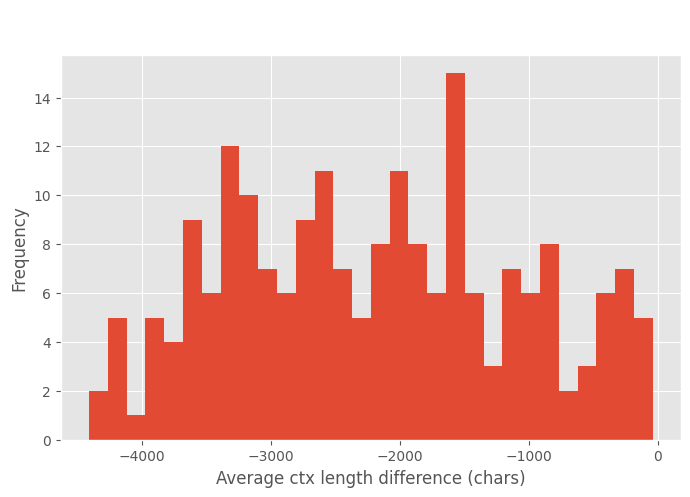

In [43]:
ax = comparison['avg_char_diff'].plot(
    kind='hist',
    bins=30,
    figsize=(8, 5),
    title='Distribution of per-query average ctx length difference\n(summ - base)'
)
ax.set_xlabel('Average ctx length difference (chars)')
plt.show()

In [44]:
comparison.sort_values('avg_char_diff').head(10)[
    ['query_idx', 'question', 'ctx_avg_chars_base', 'ctx_avg_chars_summ', 'avg_char_diff']
]

,query_idx,question,ctx_avg_chars_base,ctx_avg_chars_summ,avg_char_diff
110,110,"On May 25, 2017 Greg Gianforte won the special...",4928.6,522.2,-4406.4
60,60,What is the nationality of the author of Fifty...,4724.0,360.8,-4363.2
56,56,After coaching the red raiders to several winn...,4617.0,426.6,-4190.4
130,130,What form of play does Yameen and Activision h...,4734.2,591.4,-4142.8
73,73,"Which is in the pop genre, Capital Cities or T...",4550.4,409.8,-4140.6
168,168,"What colors are worn by the Oregon Duck, masco...",4443.0,303.2,-4139.8
177,177,The player who laid motionless for ten minutes...,4610.2,493.2,-4117.0
41,41,For what type of work is the production compan...,4557.8,551.4,-4006.4
176,176,John Paesano wrote which film for DreamWorks D...,4419.8,464.0,-3955.8
54,54,What championship did the person who substitut...,4348.0,424.6,-3923.4


In [45]:
comparison.sort_values('avg_char_diff', ascending=False).head(10)[
    ['query_idx', 'question', 'ctx_avg_chars_base', 'ctx_avg_chars_summ', 'avg_char_diff']
]

,query_idx,question,ctx_avg_chars_base,ctx_avg_chars_summ,avg_char_diff
148,148,The FIBT World Championships 1960 took place i...,701.2,661.0,-40.2
143,143,Roger Stuart Woolhouse is a biographer of a ph...,2270.4,2162.0,-108.4
195,195,what is the group called that Dianne Morgan an...,3791.0,3679.0,-112.0
72,72,What was the Roud Folk Song Index of the nurse...,2430.4,2275.8,-154.6
98,98,The owner of radio station KWPW has the same n...,2535.0,2370.0,-165.0
145,145,"The telenova ""El Ardiente Secreto"" was based o...",2902.4,2711.6,-190.8
136,136,Who is a winner of the 2013 6 Hours of Silvers...,1868.2,1677.0,-191.2
104,104,Migene González-Wippler is leading expert on a...,3525.2,3289.6,-235.6
15,15,Professional cyclist Sara Symington competed i...,3693.0,3450.0,-243.0
48,48,"Which mountain is higher, Tongshanjiabu or Him...",3002.8,2729.6,-273.2
